<a href="https://colab.research.google.com/github/Gokul-S777/ioe-ece5801/blob/main/exp5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 SMART HOSPITAL LIVE PATIENT MONITORING 
Patients Processed : 7/25
Elapsed Time       : 30 seconds



,Patient,Temperature (°C),Heart Rate (BPM),SpO₂ (%),Status
0,P01,39.7,114,97,EMERGENCY
1,P02,37.0,105,89,EMERGENCY
2,P03,36.9,60,90,EMERGENCY
3,P04,36.4,62,93,EMERGENCY
4,P05,37.0,63,91,EMERGENCY
5,P06,39.7,117,90,EMERGENCY
6,P07,36.2,103,94,EMERGENCY



Normal Patients    : 0
Emergency Patients : 7

🚨 EMERGENCY ALERT 🚨


,Patient,Temperature (°C),Heart Rate (BPM),SpO₂ (%),Status
0,P01,39.7,114,97,EMERGENCY
1,P02,37.0,105,89,EMERGENCY
2,P03,36.9,60,90,EMERGENCY
3,P04,36.4,62,93,EMERGENCY
4,P05,37.0,63,91,EMERGENCY
5,P06,39.7,117,90,EMERGENCY
6,P07,36.2,103,94,EMERGENCY


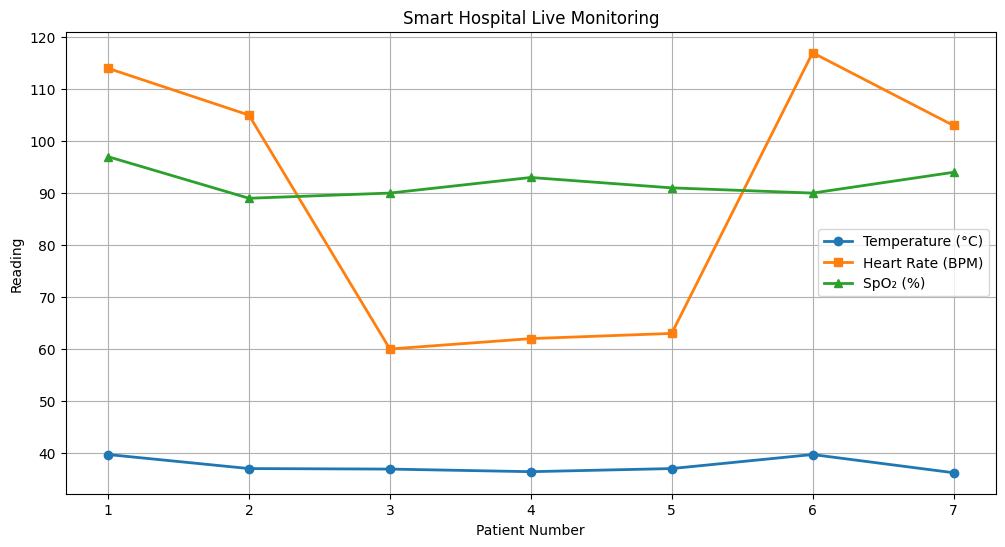

KeyboardInterrupt: 

In [1]:
# ==========================================================
# SMART HOSPITAL LIVE PATIENT MONITORING SYSTEM
# ==========================================================

import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# ==========================================================
# SETTINGS
# ==========================================================

TOTAL_PATIENTS = 25          # Total number of patients
UPDATE_INTERVAL = 5          # Seconds between patients

# ==========================================================
# STORAGE LISTS
# ==========================================================

patient_ids = []
temperatures = []
heart_rates = []
spo2_values = []
status_list = []
time_axis = []

# ==========================================================
# FUNCTION TO GENERATE PATIENT DATA
# ==========================================================

def generate_patient():

    temperature = round(random.uniform(35.5, 40.5), 1)
    heart_rate = random.randint(60, 120)
    spo2 = random.randint(88, 100)

    if temperature >= 38 or heart_rate > 100 or spo2 < 95:
        status = "EMERGENCY"
    else:
        status = "NORMAL"

    return temperature, heart_rate, spo2, status

# ==========================================================
# LIVE GRAPH FUNCTION
# ==========================================================

def live_graph():

    plt.figure(figsize=(12,6))

    plt.plot(time_axis, temperatures, marker='o', linewidth=2, label="Temperature (°C)")
    plt.plot(time_axis, heart_rates, marker='s', linewidth=2, label="Heart Rate (BPM)")
    plt.plot(time_axis, spo2_values, marker='^', linewidth=2, label="SpO₂ (%)")

    plt.title("Smart Hospital Live Monitoring")
    plt.xlabel("Patient Number")
    plt.ylabel("Reading")
    plt.grid(True)
    plt.legend()

    plt.show()

# ==========================================================
# LIVE MONITORING LOOP
# ==========================================================

for patient in range(1, TOTAL_PATIENTS + 1):

    temperature, heart_rate, spo2, status = generate_patient()

    patient_ids.append(f"P{patient:02d}")
    temperatures.append(temperature)
    heart_rates.append(heart_rate)
    spo2_values.append(spo2)
    status_list.append(status)
    time_axis.append(patient)

    df = pd.DataFrame({
        "Patient": patient_ids,
        "Temperature (°C)": temperatures,
        "Heart Rate (BPM)": heart_rates,
        "SpO₂ (%)": spo2_values,
        "Status": status_list
    })

    clear_output(wait=True)

    print("=" * 70)
    print(" SMART HOSPITAL LIVE PATIENT MONITORING ")
    print("=" * 70)

    print(f"Patients Processed : {patient}/{TOTAL_PATIENTS}")
    print(f"Elapsed Time       : {(patient-1)*UPDATE_INTERVAL} seconds\n")

    display(df)

    emergency = df[df["Status"] == "EMERGENCY"]

    print("\nNormal Patients    :", len(df) - len(emergency))
    print("Emergency Patients :", len(emergency))

    if len(emergency) > 0:
        print("\n🚨 EMERGENCY ALERT 🚨")
        display(emergency)

    live_graph()

    if patient != TOTAL_PATIENTS:
        time.sleep(UPDATE_INTERVAL)

# ==========================================================
# FINAL REPORT
# ==========================================================

print("\n")
print("=" * 70)
print("MONITORING COMPLETED SUCCESSFULLY")
print("=" * 70)

final_df = pd.DataFrame({
    "Patient": patient_ids,
    "Temperature (°C)": temperatures,
    "Heart Rate (BPM)": heart_rates,
    "SpO₂ (%)": spo2_values,
    "Status": status_list
})

display(final_df)

final_df.to_csv("Smart_Hospital_Report.csv", index=False)

print("\nCSV file saved as Smart_Hospital_Report.csv")